# Long-Horizon Stability on IEEE 118-Bus

This notebook separates two questions that are easy to conflate:

1. **Linear operator stability** — does repeated application of the learned
   Koopman matrix `K` in latent space stay bounded?
2. **End-to-end forecast quality** — does decoded physical RMSE stay low
   over a long open-loop rollout?

Structural parameterizations (`schur`, `dissipative`, `lyapunov`) **guarantee**
the first property by forcing eigenvalues strictly inside the unit disk
(with a small interior margin). They do **not** automatically guarantee the
second: encoder/decoder error and one-step mismatch still accumulate.

We use a **controlled ablation**: one encoder/decoder pair is trained
end-to-end with dense `K`; a Lyapunov-constrained model then reuses those
weights and retrains **only** `K`. Rollouts are evaluated on a 200-step
held-out horizon with ground-truth IEEE 118 snapshots.

In [1]:
import warnings
from tqdm.std import TqdmWarning

warnings.filterwarnings('ignore', category=TqdmWarning)

import os

import matplotlib

if os.environ.get('PYTEST_CURRENT_TEST'):
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
import numpy as np
import torch

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get('PYTEST_CURRENT_TEST'):
        get_ipython().run_line_magic('matplotlib', 'inline')
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.datasets import IEEE118DynamicBenchmark


## Train / holdout split

We generate **240** snapshots: **40** for training and **200** held-out for
open-loop evaluation. Rollout starts from the final training snapshot and
compares every decoded step to the corresponding held-out ground truth.

In [2]:
TRAIN_STEPS = 40
ROLLOUT_STEPS = 200
TOTAL_STEPS = TRAIN_STEPS + ROLLOUT_STEPS

torch.manual_seed(0)
full_sequence = IEEE118DynamicBenchmark.generate(
    num_timesteps=TOTAL_STEPS,
    seed=42,
)
train_sequence = full_sequence.slice(0, TRAIN_STEPS)

in_channels = full_sequence.in_channels
latent_dim = 32
hidden = 64
time_step = 0.1

print(
    f'Buses: {full_sequence.num_nodes}, features: {in_channels}, '
    f'train={train_sequence.num_timesteps}, holdout={ROLLOUT_STEPS}'
)


Buses: 118, features: 4, train=40, holdout=200


## Controlled ablation: shared encoder/decoder, different `K`

1. Train **dense** `K` end-to-end on the training window.
2. Build a **Lyapunov** model, copy the trained encoder/decoder weights, freeze
   them, and fit **only** the Koopman operator on the same training data.

This isolates the effect of operator parameterization while holding the
lifting and reconstruction maps fixed.

In [3]:
def build_model(parameterization: str) -> GraphKoopmanModel:
    encoder = GNNEncoder(
        in_channels=in_channels,
        hidden_channels=hidden,
        latent_dim=latent_dim,
    )
    decoder = GNNDecoder(
        latent_dim=latent_dim,
        hidden_channels=hidden,
        out_channels=in_channels,
    )
    return GraphKoopmanModel(
        encoder=encoder,
        decoder=decoder,
        latent_dim=latent_dim,
        time_step=time_step,
        koopman_parameterization=parameterization,
    )


def copy_encoder_decoder(source: GraphKoopmanModel, target: GraphKoopmanModel) -> None:
    target.encoder.load_state_dict(source.encoder.state_dict())
    target.decoder.load_state_dict(source.decoder.state_dict())


def freeze_encoder_decoder(model: GraphKoopmanModel) -> None:
    for param in model.encoder.parameters():
        param.requires_grad = False
    for param in model.decoder.parameters():
        param.requires_grad = False


dense_model = build_model('dense')
dense_model.fit(train_sequence, epochs=15, lr=1e-3)

stable_model = build_model('lyapunov')
copy_encoder_decoder(dense_model, stable_model)
freeze_encoder_decoder(stable_model)
stable_model.fit(train_sequence, epochs=15, lr=1e-3)

cert = stable_model.koopman.stability_certificate()
print('Lyapunov margin:', float(cert.margin.detach()))
print('Lyapunov bound_metric:', float(stable_model.koopman.bound_metric().detach()))
print('Lyapunov spectral radius (true):', float(stable_model.koopman.spectral_radius().detach()))
print('Dense spectral radius (true):', float(dense_model.koopman.spectral_radius().detach()))


Lyapunov margin: 0.00010097026824951172
Lyapunov bound_metric: 0.9998990297317505
Lyapunov spectral radius (true): 0.9998996257781982
Dense spectral radius (true): 1.114484190940857


## 200-step rollout: decoded RMSE and latent norm

Both metrics are reported on **every** rollout step against held-out ground
truth:

- **Decoded RMSE** — physical-space error after the GNN decoder (forecast quality).
- **Latent norm** — `‖z‖₂` after each linear `K` step (operator stability proxy).

A structurally stable `K` should keep latent norms bounded. Decoded RMSE can
still grow if the encoder/decoder do not perfectly represent the dynamics.

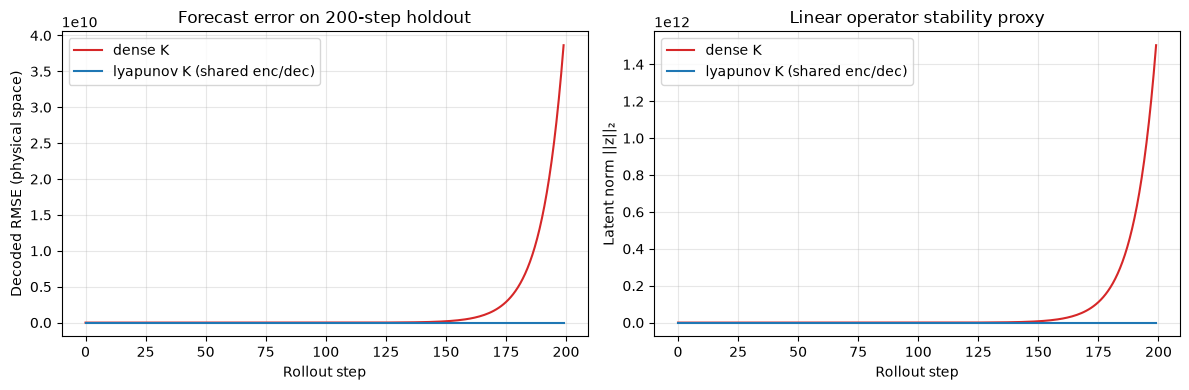

Final decoded RMSE — dense: 38644297728.0000, lyapunov: 2.5582
Final latent norm — dense: 1503797575680.0000, lyapunov: 84.5252
Mean decoded RMSE (last 50 steps) — dense: 7489063828.4800, lyapunov: 2.5140


In [4]:
def rollout_metrics(
    model: GraphKoopmanModel,
    *,
    initial_idx: int,
    steps: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Return latent norms and decoded RMSE for each open-loop step."""
    model.eval()
    initial = full_sequence[initial_idx]
    edge_index = initial.edge_index
    latent_norms: list[float] = []
    rmse_values: list[float] = []

    with torch.no_grad():
        z = model.encoder(initial, edge_index)
        for step in range(steps):
            z = model.koopman(z)
            pred_x = model.decoder(z, edge_index)
            latent_norms.append(float(z.norm().item()))
            target_x = full_sequence[initial_idx + 1 + step].x
            rmse = torch.sqrt(((pred_x - target_x) ** 2).mean()).item()
            rmse_values.append(rmse)

    return np.asarray(latent_norms), np.asarray(rmse_values)


initial_idx = TRAIN_STEPS - 1
dense_latent, dense_rmse = rollout_metrics(
    dense_model,
    initial_idx=initial_idx,
    steps=ROLLOUT_STEPS,
)
stable_latent, stable_rmse = rollout_metrics(
    stable_model,
    initial_idx=initial_idx,
    steps=ROLLOUT_STEPS,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(dense_rmse, label='dense K', color='tab:red')
axes[0].plot(stable_rmse, label='lyapunov K (shared enc/dec)', color='tab:blue')
axes[0].set_xlabel('Rollout step')
axes[0].set_ylabel('Decoded RMSE (physical space)')
axes[0].set_title('Forecast error on 200-step holdout')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(dense_latent, label='dense K', color='tab:red')
axes[1].plot(stable_latent, label='lyapunov K (shared enc/dec)', color='tab:blue')
axes[1].set_xlabel('Rollout step')
axes[1].set_ylabel('Latent norm ||z||₂')
axes[1].set_title('Linear operator stability proxy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final decoded RMSE — dense: {dense_rmse[-1]:.4f}, lyapunov: {stable_rmse[-1]:.4f}')
print(f'Final latent norm — dense: {dense_latent[-1]:.4f}, lyapunov: {stable_latent[-1]:.4f}')
print(
    f'Mean decoded RMSE (last 50 steps) — dense: {dense_rmse[-50:].mean():.4f}, '
    f'lyapunov: {stable_rmse[-50:].mean():.4f}'
)


## Takeaways

- **What structural parameterizations guarantee:** eigenvalues of `K` stay
  strictly inside the unit disk, so repeated *linear* latent propagation
  cannot blow up exponentially. Inspect `model.koopman.stability_certificate()`
  and `bound_metric()` (closed-form) / `spectral_radius()` (true eigvals) to
  verify this.
- **What they do not guarantee:** low decoded RMSE on long horizons. That
  depends on encoder/decoder quality and one-step model error, which still
  compounds during open-loop rollout even when `‖z‖₂` is bounded.
- **This experiment's design:** shared encoder/decoder isolate the effect of
  `K`; the 200-step holdout supplies ground-truth physical targets for every
  rollout step.
- **Soft regularization contrast:** ODO `bound_metric()` only tracks the
  diagonal-factor bound (not a structural certificate); pair with eigenvalue
  loss or switch to structural modes (see
  [`08_loss_stability.ipynb`](08_loss_stability.ipynb)). This notebook
  demonstrates **hard** spectral constraints, not a head-to-head benchmark
  against those methods.

Interpret the left panel as **forecast quality** and the right panel as
**operator stability** — related, but not the same claim.